(sec:openqm-jump-example)=
# A Simple example of the jump method


Let us calculate a quantum trajectory of thermal fluorescence from a single emitter using the same model as used in the example of quantum master equation. (See {numref}`sec:openqm-qme-example`.)


## Calculating jumps
`QuTiP` has a built-in routine to calculate quantum trajectory.  In order to understand the algorithm, we write our own code. It is too slow for real applications. Use `QuTiP` instead. 

In the following code, the simulation continues until the photon counts reaches the maximum. It takes a while to complete the simulation if a large number of photons are specified.   At each time step, $\langle \sigma_z \rangle$ is computed and the time a photon is emitted is recorded.  This code takes several minutes or more to complete. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

def schroedinger(H,psi,dt):
    psi_new = (1 - 1j*H*dt) * psi
    return psi_new

def jump(c_ops,psi,dq):
    r = rng.random()
    if r < dq[1]:
        psi_new = c_ops[1] * psi
        flag=1
    else:
        psi_new = c_ops[0] * psi
        flag=0
    return psi_new,flag

# System parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
N = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# Collapse operators
gamma1 = gamma0 * N   # coefficient to absorption
gamma2 = gamma0 * (N+1)  # coefficient to emission
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]
n = np.zeros([len(c_ops),1])
dq = np.zeros([len(c_ops),1])

# Effective Hamiltonian for a two-level system
H = 0.5 * omega0 * sigmaz()
for i in range(len(c_ops)):
    H += - 0.5j * c_ops[i].dag() * c_ops[i]

# set arrays for record
times = np.array([])   # time
spikes = np.array([])  # time when a photon is emitted
sz = np.array([]) # expectation value of sigma_z

# control parameters
# maximum number of photons to be counted
max_photons = 1000

# time step
dt = 0.1  

# number of photons emitted
n_photons = 0 

# current time
k=0 # loop counter
times = np.append(times,k*dt)

# random initial state vector
theta = rng.random()*2*np.pi
psi = basis(2,0)*np.sin(theta) + basis(2,1)*np.cos(theta)

# we measure sigmaz
sz = np.append(sz,expect(sigmaz(),psi))

# main loop begins
n_absorption = 0

while n_photons < max_photons:

# set new time
    k += 1
    times = np.append(times,k*dt)

# calculate jump probability

    for j in range(len(c_ops)):
       n[j] = expect(c_ops[j].dag() * c_ops[j], psi)*dt
    dp = sum(n)
    dq = n/dp

# choose schroedinger or jump step at random
    if rng.random() > dp:
        # Schroedinger step
        psi_new = schroedinger(H,psi,dt)

    else:
        # Jump step
        psi_new, flag = jump(c_ops,psi,dq)
        if flag == 1:  # emission
            spikes = np.append(spikes,times[k])
            n_photons += 1
        else:
            n_absorption += 1

# set the state vector for next cycle
    psi=psi_new.unit()

# record the expectation value
    sz = np.append(sz,expect(sigmaz(),psi))
    
print("number of emissions  =", n_photons, "   rate =",n_photons/times[-1])
print("number of absorption =", n_absorption, "   rate =",n_absorption/times[-1])

number of emissions  = 1000    rate = 0.04375620791199751
number of absorption = 999    rate = 0.04371245170408551


## Plots of quantum trajectory

First, we plot the quantum trajectory and the spike train of the first 50 photons. Compare the spikes of photon with three statistical types discussed in {numref}`ch:bunching-fcs`.

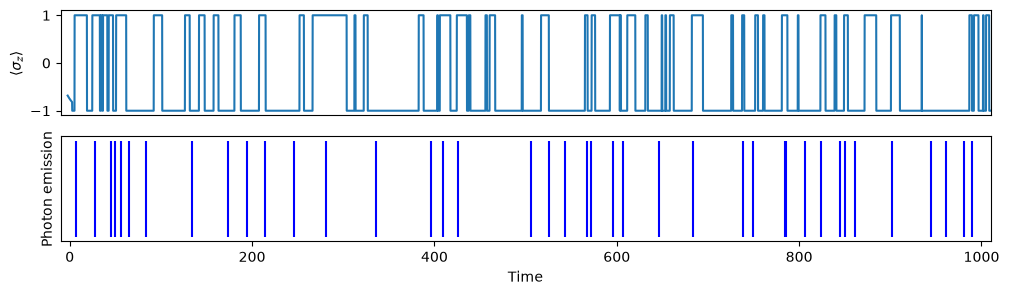

In [2]:
max_time = spikes[50]

plt.figure(figsize=(12, 3))
plt.subplot(2,1,1)
plt.plot(times,sz)
plt.xticks([])
plt.xlim([-10,max_time+10])
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.subplot(2,1,2)
plt.xlim([-10,1010])
plt.yticks([])
plt.xlabel("Time")
plt.ylabel("Photon emission")
plt.vlines(spikes, 0, 1, color='b', label="emission")
plt.show()

## Waiting time distribution and statistics

In the above example, we have a very limited sampling.  Nevertheless, we attempt to make a statistical analysis as a practice.  We generate collection of waiting time and evaluate statistical information.  Since the variance is smaller than the mean squared, the distribution is most likely sub-poissonian and thus anti-bunching is expected, in consistent with $g^{(2)}(\tau)$ obtained by the quantum master equation.

mean waiting time  =  22.87037037037037
standard deviation =  17.518597667256117
likely sub-poissonian


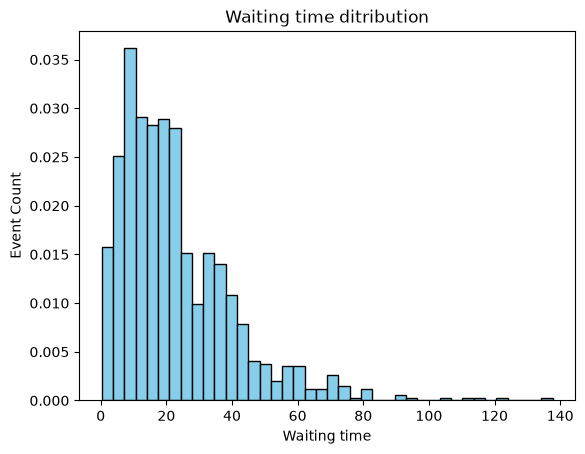

In [3]:
wtime = np.array([])
for i in range(max_photons-1):
    wtime = np.append(wtime,spikes[i+1]-spikes[i])

mean = sum(wtime)/len(wtime)
dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

print("mean waiting time  = ",mean)
print("standard deviation = ",dev)

if dev < 0.9*mean:
    print("likely sub-poissonian")
elif dev > 1.1*mean:
    print("likely super-poissonian")
else:
    print("likely poissonian")
    
plt.hist(wtime, density=True, bins=40, color='skyblue', edgecolor='black')
plt.title("Waiting time ditribution")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()


## Calculation of second-order coherence

Calculating $g^{(2)}(\tau)$ from the spike train of photons is strait forward as discussed in {numref}`ch:bunching-fcs`.  For a spike train $\{t_{1}, t_{2}, \cdots, t_{N}\}$ of $N$ photons, the number of photons separated by time difference  $\tau$ is given by [same as Eq. {eq}`eq:pair_counting`]

$$
n(\tau) = \sum_{i < j} \delta(\tau - t_{j}+t_{i})
$$

which is proportional to $g^{(2)}(\tau)$.  We must scale $n(\tau)$ so that  $g^{(2)}(\tau)$ is appropriately normalized.  Due to the presence of delta function,  Equation {eq}`eq:pair_counting` is numerically not practical. We usually plot it as a histogram, which shows the number of photons per the bin width $\Delta \tau$. Since $g^{(2)}$ is dimensionless, the scaling functor must cancel $\Delta t$. Recall that $\lim_{\tau\rightarrow\infty} g^{(2)}(\tau) = 1$.  That means there is no correlation at a large $\tau$.  Then, $n(\tau)$ also does not depend on $\tau$.  Now, we evaluate $n$ when there is no correlation. The summation over $i$ generates $N$.   The summation over $j$ counts the average number of photons with $\Delta \tau$, which is $N \Delta \tau / t_\text{max}$ where $t_\text{max}$ is total measurement time.  Thus $n(\infty) \approx N^2 \Delta \tau / t_\text{max}$. Finally we have a properly normalized $g^{(2)}(\tau)$ as
$$
g^{(2)}(\tau) = \frac{n(\tau)}{n(\infty)}  = \frac{n(\tau) t_\text{max}}{N \Delta \tau}
$$

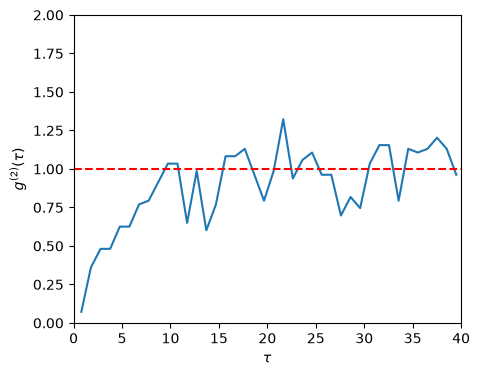

In [4]:
tau_max = 40  # max correlation time
N_spikes = len(spikes)
dN = 50

def pair_times(spikes):

    time_gap = np.array([])
    i=1


    while i < N_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j < N_spikes) :
            t1 = spikes[j]
            if t1-t0 <= tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
    return time_gap

pair_time_gap = pair_times(spikes)

nbins = 40
dtau = tau_max/nbins
norm = (N_spikes-dN)*N_spikes /spikes[N_spikes-1] * dtau 

counts, bin = np.histogram(pair_time_gap, bins=nbins)
n=len(bin)
x = (bin[0:n-1]+bin[1:n])/2
y = counts/norm

plt.figure(figsize=(5, 4))
plt.ylim([0,2])
plt.plot(x,y)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

## Using QuTiP routines

Let us calcuate the same trajectory using QuTiP routine `mcsolve` generates quantum trajectories.  The arguments are essetially the same used for `qmesolv()`.  See {numref}`ch:qutip` for its usage.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

# System parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
N = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# Collapse operators
gamma1 = gamma0 * N   # coefficient to absorption
gamma2 = gamma0 * (N+1)  # coefficient to emission
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]

# system Hamiltonian 
#(Do not add collapse operator here since mcsolve() add it.
H = 0.5*omega0*sigmaz()

# initially in the ground state
psi0 = basis(2,1)

# execution time (trying to get 1000 photons)
tmax = 24000
# number of time sampling points
tsample = 2400
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=[sigmap()*sigmam()],ntraj=1,options=opts)

# get results
t_jump = np.array(result.col_times) # time of all jumps
ch_jump = np.array(result.col_which) # channel of all jumps

t_absorption = t_jump[ch_jump==0]
t_emission = t_jump[ch_jump==1]

# is there enough counts?
# is there enough counts?
print("Number of absorptions =", len(t_absorption)," rate =",len(t_absorption)/times[-1])
print("Number of emissions   =", len(t_emission)," rate =",len(t_emission)/times[-1])

Number of absorptions = 1040  rate = 0.043333333333333335
Number of emissions   = 1040  rate = 0.043333333333333335
